In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [35]:
df = pd.read_csv("crossborder_ecommerce.csv")

df.head()

,user_id,country,age,session_duration,pages_viewed,click_through_rate,total_orders,avg_order_value,loyalty_score,conversion
0,U1000,Germany,45,321,16,0.29,1,19.87,2,1
1,U1001,Brazil,24,235,19,0.30,2,91.21,3,0
2,U1002,India,49,225,2,0.89,9,110.76,5,1
3,U1003,Brazil,28,429,12,0.70,11,23.19,6,0
4,U1004,Brazil,27,113,14,0.57,6,98.73,7,1


In [5]:
print("Shape:", df.shape)

df.info()

df.describe(include="all").T

Shape: (2000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             2000 non-null   str    
 1   country             2000 non-null   str    
 2   age                 2000 non-null   int64  
 3   session_duration    2000 non-null   int64  
 4   pages_viewed        2000 non-null   int64  
 5   click_through_rate  2000 non-null   float64
 6   total_orders        2000 non-null   int64  
 7   avg_order_value     2000 non-null   float64
 8   loyalty_score       2000 non-null   int64  
 9   conversion          2000 non-null   int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 156.4 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,2000,2000,U1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2000,5,US,415,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2000.0,NaN,NaN,NaN,38.5795,12.065715,18.0,28.0,38.0,49.0,59.0
session_duration,2000.0,NaN,NaN,NaN,332.421,155.405467,60.0,197.75,331.0,472.0,599.0
pages_viewed,2000.0,NaN,NaN,NaN,12.439,6.91695,1.0,6.0,12.0,18.0,24.0
click_through_rate,2000.0,NaN,NaN,NaN,0.48772,0.258433,0.05,0.27,0.48,0.71,0.95
total_orders,2000.0,NaN,NaN,NaN,7.1835,4.263909,0.0,4.0,7.0,11.0,14.0
avg_order_value,2000.0,NaN,NaN,NaN,78.92389,40.480658,10.03,45.4275,78.375,112.8375,149.95
loyalty_score,2000.0,NaN,NaN,NaN,4.941,2.568232,1.0,3.0,5.0,7.0,9.0
conversion,2000.0,NaN,NaN,NaN,0.4285,0.494985,0.0,0.0,0.0,1.0,1.0


In [6]:
df.columns

Index(['user_id', 'country', 'age', 'session_duration', 'pages_viewed',
       'click_through_rate', 'total_orders', 'avg_order_value',
       'loyalty_score', 'conversion'],
      dtype='str')

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

user_id               0
country               0
age                   0
session_duration      0
pages_viewed          0
click_through_rate    0
total_orders          0
avg_order_value       0
loyalty_score         0
conversion            0
dtype: int64


In [8]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

user_id               0
country               0
age                   0
session_duration      0
pages_viewed          0
click_through_rate    0
total_orders          0
avg_order_value       0
loyalty_score         0
conversion            0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# Analysis for categorial data useful or not and how dataset is uniform distributed or not

In [12]:
numeric_cols = [
    "age",
    "session_duration",
    "pages_viewed",
    "click_through_rate",
    "total_orders",
    "avg_order_value",
    "loyalty_score"
]

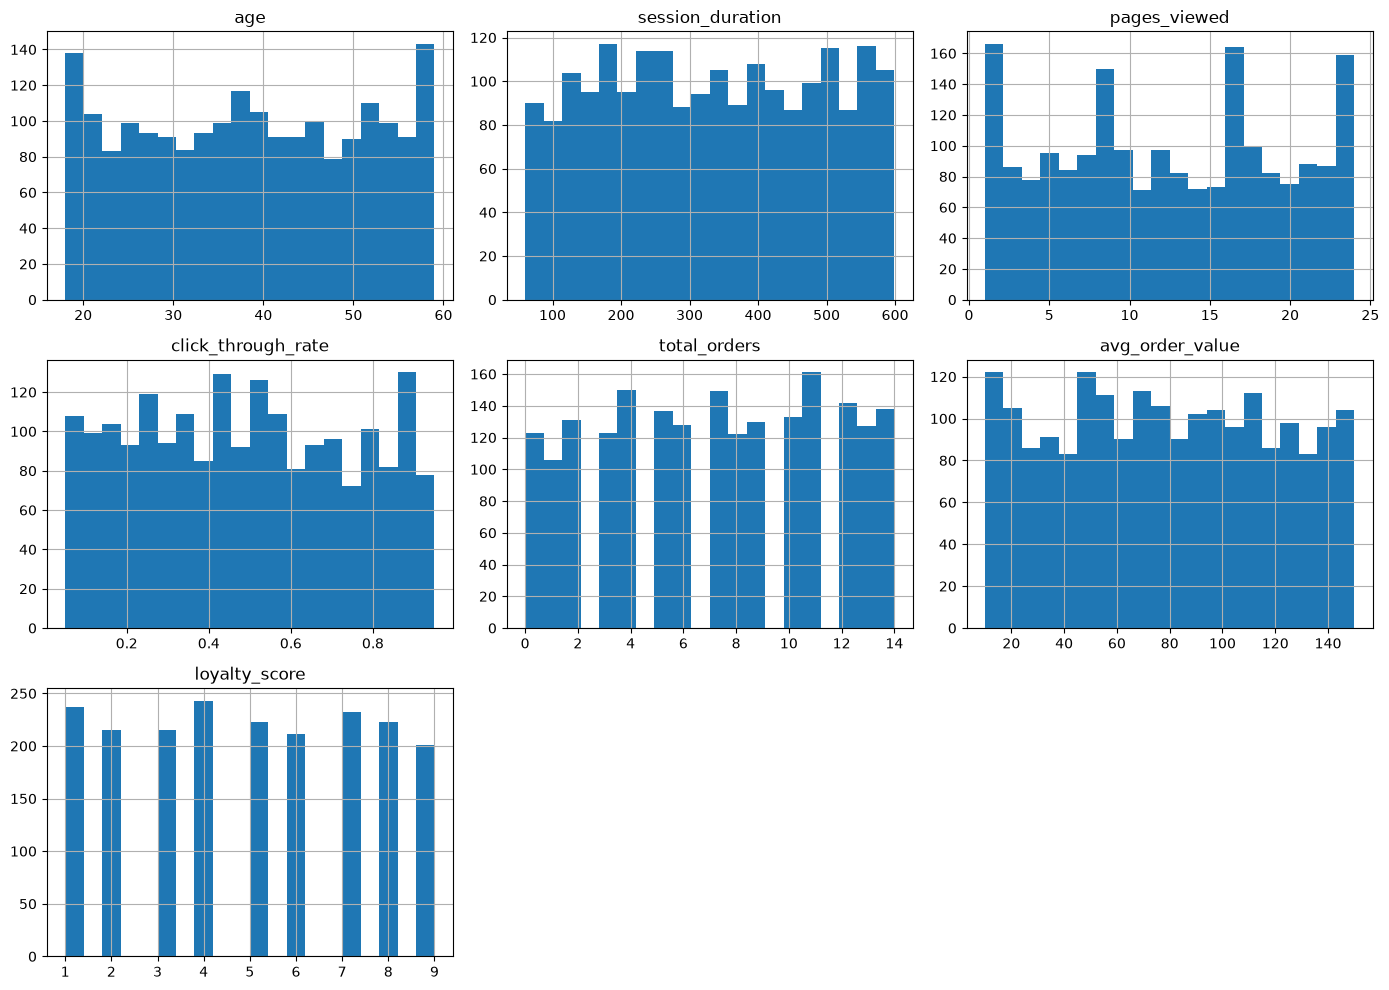

In [13]:
df[numeric_cols].hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

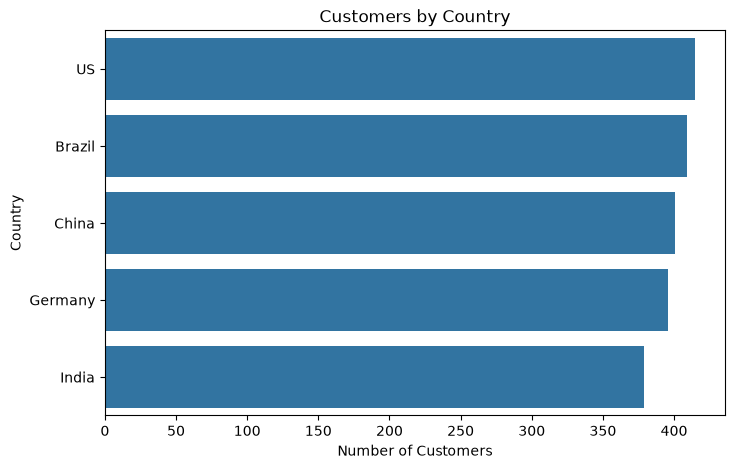

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="country",
    order=df["country"].value_counts().index
)

plt.title("Customers by Country")
plt.xlabel("Number of Customers")
plt.ylabel("Country")

plt.show()

In [15]:
country_conversion = (
    df.groupby("country")["conversion"]
      .mean()
      .sort_values(ascending=False)
)

print(country_conversion)

country
Germany    0.474747
US         0.438554
Brazil     0.435208
China      0.433915
India      0.356201
Name: conversion, dtype: float64


In [16]:
print(country_conversion * 100)

country
Germany    47.474747
US         43.855422
Brazil     43.520782
China      43.391521
India      35.620053
Name: conversion, dtype: float64


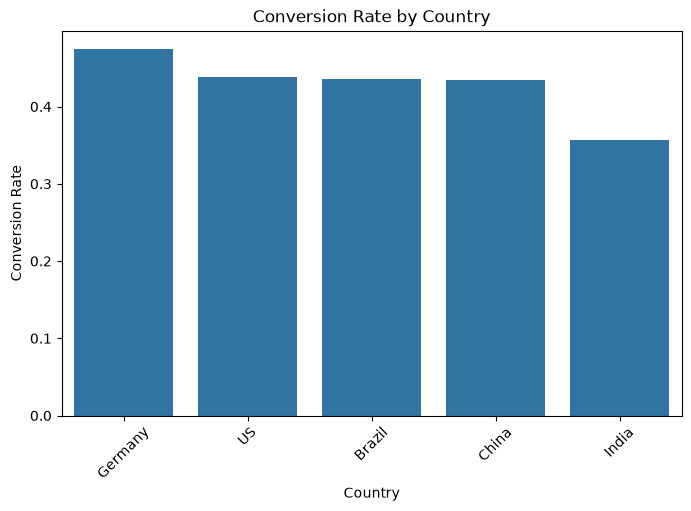

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=country_conversion.index,
    y=country_conversion.values
)

plt.title("Conversion Rate by Country")
plt.ylabel("Conversion Rate")
plt.xlabel("Country")

plt.xticks(rotation=45)
plt.show()

#Check outliers

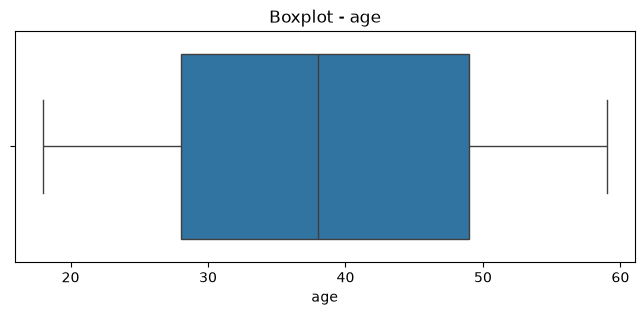

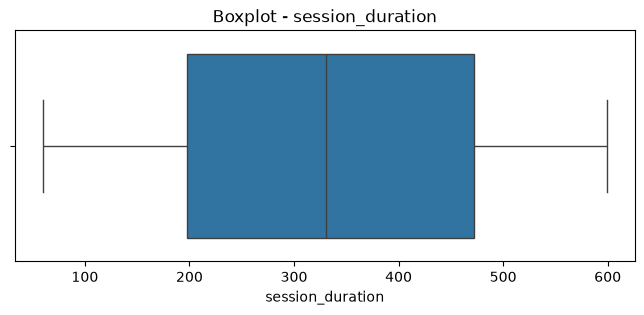

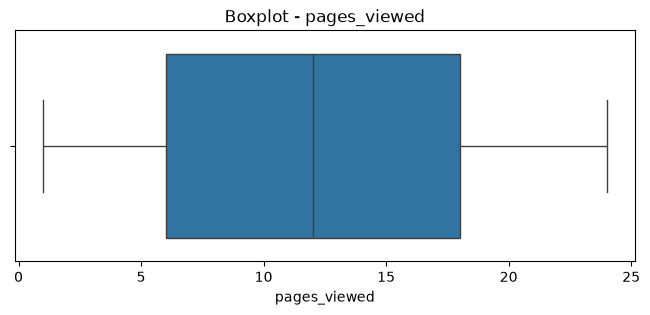

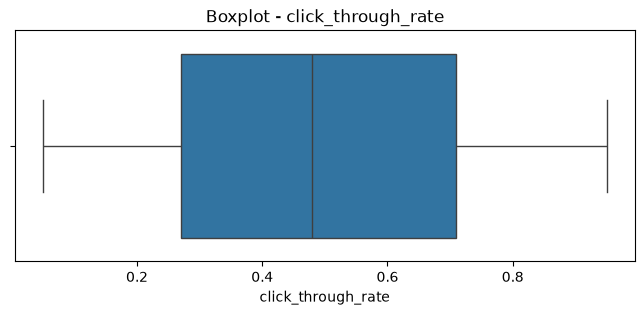

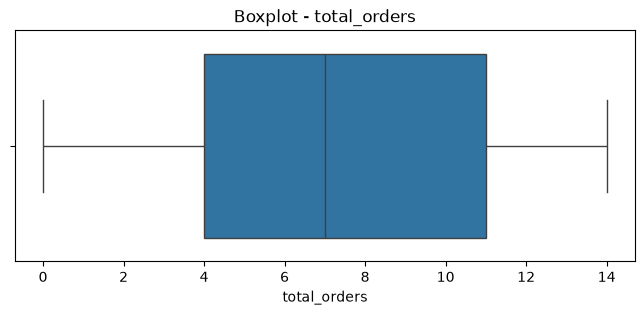

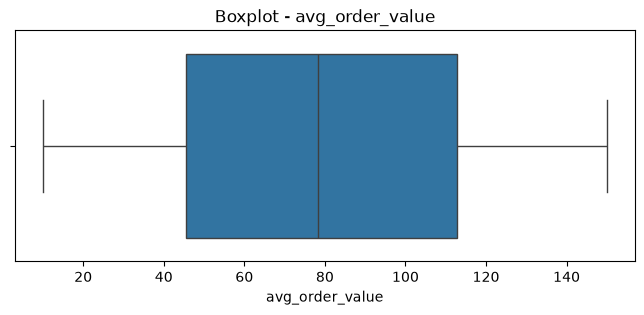

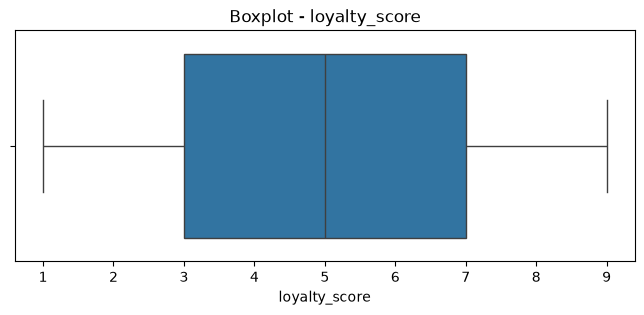

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot - {col}")
    plt.show()

It not show any outlier

# correlation


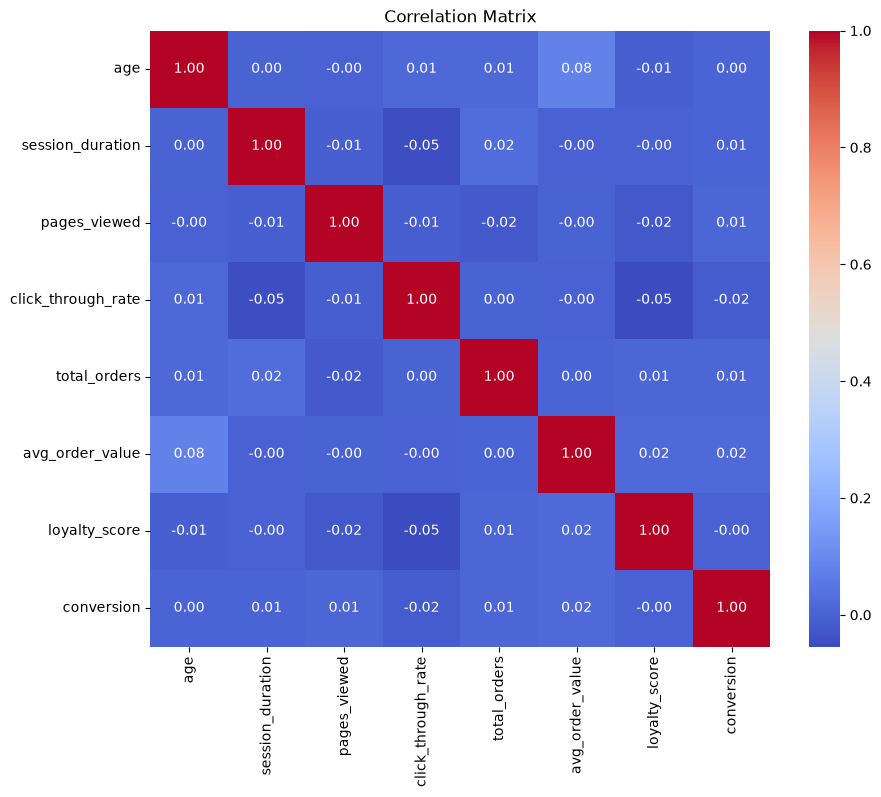

In [19]:
plt.figure(figsize=(10,8))

corr = df[numeric_cols + ["conversion"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# convert Categorical data to numerical

In [37]:
df_numeric = pd.get_dummies(
    df.drop("user_id", axis=1),
    columns=["country"],
    drop_first=True,
    dtype=int
)

In [40]:
df_numeric.head()

,age,session_duration,pages_viewed,click_through_rate,total_orders,avg_order_value,loyalty_score,conversion,country_China,country_Germany,country_India,country_US
0,45,321,16,0.29,1,19.87,2,1,0,1,0,0
1,24,235,19,0.30,2,91.21,3,0,0,0,0,0
2,49,225,2,0.89,9,110.76,5,1,0,0,1,0
3,28,429,12,0.70,11,23.19,6,0,0,0,0,0
4,27,113,14,0.57,6,98.73,7,1,0,0,0,0


Split data x and y

In [41]:
X = df_numeric.drop("conversion", axis=1)
y = df_numeric["conversion"]

In [45]:
# Split the data into training, validation and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

X_train, X_val, y_train, y_val = train_test_split( X_train_full,y_train_full,test_size=0.25,random_state=42)

In [51]:
# 1. Logistic Regression
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

In [52]:
#2. Random Forest

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

In [53]:
#svc
svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

svc_params = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

In [54]:
models = {
    "Logistic Regression": (logistic_pipeline, logistic_params),
    "Random Forest": (rf_pipeline, rf_params),
    "SVC": (svc_pipeline, svc_params)
}

In [56]:
# Logistic Regression
logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Logistic Regression")
print("Best Parameters:", logistic_grid.best_params_)
print("Best CV F1:", logistic_grid.best_score_)

Logistic Regression
Best Parameters: {'model__C': 0.01, 'model__solver': 'liblinear'}
Best CV F1: 0.19504524333577894


In [57]:
# Random Forest
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Random Forest")
print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Random Forest
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV F1: 0.32778079861695314


In [58]:
# SVC
svc_grid = GridSearchCV(
    svc_pipeline,
    svc_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svc_grid.fit(X_train, y_train)

print("SVC")
print("Best Parameters:", svc_grid.best_params_)
print("Best CV F1:", svc_grid.best_score_)

c:\Users\31asa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC
Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV F1: 0.4287497136205178
